# Assignment 08 - Soil Health and Sustainability

This notebook analyzes NRCS soil indicators for Lea, Roosevelt, and Curry counties. It computes a field-level Soil Health Score using organic matter (OM), pH, and cation exchange capacity (CEC), identifies erosion-risk fields using available slope gradients, estimates a simple carbon storage potential metric, and exports dashboard-ready visual assets.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
DASHBOARD_ASSETS_DIR = OUTPUT_DIR / "dashboard_assets"
DASHBOARD_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

soil_path = DATA_DIR / "soil" / "nm_soil_data.csv"
fields_soil_path = DATA_DIR / "assignment-02" / "fields_with_crops_soil.geojson"
crops_path = DATA_DIR / "crops" / "nm_cdl_2008_2020.csv"
county_path = DATA_DIR / "boundaries" / "nm_county_boundaries.geojson"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dashboard assets: {DASHBOARD_ASSETS_DIR}")


Project root: /workspaces/EVTLR-Project
Dashboard assets: /workspaces/EVTLR-Project/output/dashboard_assets


In [3]:
soil_df = pd.read_csv(soil_path)
fields_gdf = gpd.read_file(fields_soil_path)
crops_df = pd.read_csv(crops_path)
counties_gdf = gpd.read_file(county_path)

counties_of_interest = ["Lea", "Roosevelt", "Curry"]
fields_gdf = fields_gdf[fields_gdf["county"].isin(counties_of_interest)].copy()
counties_gdf = counties_gdf[counties_gdf["NAME"].isin(counties_of_interest)].copy()

print("Soil rows:", len(soil_df))
print("Fields in counties of interest:", len(fields_gdf))
print("Field IDs:", fields_gdf["field_id"].nunique())


Soil rows: 3945
Fields in counties of interest: 199
Field IDs: 199


In [4]:
slope_pattern = re.compile(r"(\d+(?:\.\d+)?)\s+to\s+(\d+(?:\.\d+)?)\s+percent slopes", re.IGNORECASE)

def parse_slope_mid(text: str) -> float:
    if not isinstance(text, str):
        return np.nan
    m = slope_pattern.search(text)
    if not m:
        return np.nan
    return (float(m.group(1)) + float(m.group(2))) / 2.0

soil_df["slope_mid_pct"] = soil_df["muname"].map(parse_slope_mid)

soil_df["hzdept_r"] = pd.to_numeric(soil_df["hzdept_r"], errors="coerce")
soil_df["hzdepb_r"] = pd.to_numeric(soil_df["hzdepb_r"], errors="coerce")
soil_df["comppct_r"] = pd.to_numeric(soil_df["comppct_r"], errors="coerce")

soil_df["horizon_thickness_cm"] = (soil_df["hzdepb_r"] - soil_df["hzdept_r"]).clip(lower=0)
soil_df["horizon_thickness_cm"] = soil_df["horizon_thickness_cm"].fillna(0)

soil_df["topsoil_thickness_cm"] = (
    np.minimum(soil_df["hzdepb_r"], 30) - np.maximum(soil_df["hzdept_r"], 0)
).clip(lower=0)
soil_df["topsoil_thickness_cm"] = soil_df["topsoil_thickness_cm"].fillna(0)

soil_df["agg_weight"] = soil_df["comppct_r"].fillna(0) * soil_df["horizon_thickness_cm"]
soil_df["topsoil_weight"] = soil_df["comppct_r"].fillna(0) * soil_df["topsoil_thickness_cm"]

soil_df.head()


,mukey,muname,compname,comppct_r,drainagecl,hzdept_r,hzdepb_r,om_r,ph1to1h2o_r,awc_r,claytotal_r,sandtotal_r,silttotal_r,dbthirdbar_r,cec7_r,field_id,slope_mid_pct,horizon_thickness_cm,topsoil_thickness_cm,agg_weight,topsoil_weight
0,1547903,"Kimberson gravelly loam, 0 to 3 percent slopes",Kimberson,85,Well drained,0.0,13.0,2.9,7.8,0.14,18.6,44.2,37.2,1.40,17.7,NM_FIELD_001,1.5,13.0,13.0,1105.0,1105.0
1,2441669,"Acuff very fine sandy loam, 1 to 3 percent slopes",Acuff,85,Well drained,0.0,26.0,2.1,7.2,0.12,16.1,68.0,15.9,1.50,14.0,NM_FIELD_001,2.0,26.0,26.0,2210.0,2210.0
2,2520116,"Zita very fine sandy loam, 1 to 3 percent slopes",Zita,85,Well drained,0.0,14.0,2.0,8.1,0.12,16.1,68.0,15.9,1.50,13.2,NM_FIELD_001,2.0,14.0,14.0,1190.0,1190.0
3,1547903,"Kimberson gravelly loam, 0 to 3 percent slopes",Kimberson,85,Well drained,13.0,28.0,3.3,8.0,0.13,24.6,44.7,30.7,1.38,14.3,NM_FIELD_001,1.5,15.0,15.0,1275.0,1275.0
4,2520116,"Zita very fine sandy loam, 1 to 3 percent slopes",Zita,85,Well drained,14.0,41.0,1.2,8.3,0.13,22.0,59.0,19.0,1.47,13.3,NM_FIELD_001,2.0,27.0,16.0,2295.0,1360.0


In [5]:
def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return np.nan
    return np.average(values[mask], weights=weights[mask])

records = []
for field_id, group in soil_df.groupby("field_id"):
    om = weighted_mean(group["om_r"], group["agg_weight"])
    ph = weighted_mean(group["ph1to1h2o_r"], group["agg_weight"])
    cec = weighted_mean(group["cec7_r"], group["agg_weight"])
    slope = weighted_mean(group["slope_mid_pct"], group["agg_weight"])

    topsoil_depth = weighted_mean(group["topsoil_thickness_cm"], group["comppct_r"].fillna(0))
    carbon_potential = np.nan
    if pd.notna(topsoil_depth) and pd.notna(om):
        carbon_potential = topsoil_depth * om

    drainage_weights = group.groupby("drainagecl")["comppct_r"].sum(min_count=1)
    dominant_drainage = drainage_weights.idxmax() if not drainage_weights.empty else np.nan

    records.append({
        "field_id": field_id,
        "om_weighted": om,
        "ph_weighted": ph,
        "cec_weighted": cec,
        "slope_pct": slope,
        "topsoil_depth_cm": topsoil_depth,
        "carbon_storage_potential": carbon_potential,
        "dominant_drainage": dominant_drainage,
    })

field_metrics = pd.DataFrame(records)
field_meta = fields_gdf[["field_id", "county", "area_acres"]].drop_duplicates()
field_metrics = field_metrics.merge(field_meta, on="field_id", how="inner")

field_metrics.head()


,field_id,om_weighted,ph_weighted,cec_weighted,slope_pct,topsoil_depth_cm,carbon_storage_potential,dominant_drainage,county,area_acres
0,NM_FIELD_001,1.407921,8.026841,16.949642,2.487868,13.590034,19.133689,Well drained,Roosevelt,1856.477282
1,NM_FIELD_002,0.326547,7.367635,9.352465,1.500000,22.727273,7.421523,Well drained,Lea,1795.676593
2,NM_FIELD_003,0.729079,7.488738,9.027164,1.755490,15.673981,11.427576,Well drained,Roosevelt,1795.488384
3,NM_FIELD_004,0.751213,7.813754,19.101149,1.203146,15.105740,11.347623,Well drained,Roosevelt,1639.508575
4,NM_FIELD_005,1.226712,7.830213,14.776681,6.952702,14.065640,17.254485,Well drained,Roosevelt,1588.144303


In [6]:
def minmax(series: pd.Series) -> pd.Series:
    smin, smax = series.min(skipna=True), series.max(skipna=True)
    if pd.isna(smin) or pd.isna(smax) or smin == smax:
        return pd.Series(np.nan, index=series.index)
    return (series - smin) / (smax - smin)

field_metrics["om_norm"] = minmax(field_metrics["om_weighted"])
field_metrics["cec_norm"] = minmax(field_metrics["cec_weighted"])

# pH suitability centered near neutral-agronomic target
field_metrics["ph_score"] = (1 - (field_metrics["ph_weighted"] - 6.8).abs() / 2.2).clip(lower=0, upper=1)

field_metrics["soil_health_score"] = 100 * (
    0.4 * field_metrics["om_norm"].fillna(0)
    + 0.3 * field_metrics["cec_norm"].fillna(0)
    + 0.3 * field_metrics["ph_score"].fillna(0)
)

field_metrics["erosion_risk"] = pd.cut(
    field_metrics["slope_pct"],
    bins=[-np.inf, 3, 6, np.inf],
    labels=["Low", "Moderate", "High"],
)

field_metrics = field_metrics.sort_values("soil_health_score", ascending=False).reset_index(drop=True)

print("Top fields by Soil Health Score")
display(field_metrics[["field_id", "county", "soil_health_score", "om_weighted", "ph_weighted", "cec_weighted"]].head(10))


Top fields by Soil Health Score


,field_id,county,soil_health_score,om_weighted,ph_weighted,cec_weighted
0,NM_FIELD_128,Curry,75.604765,2.341106,7.625000,16.757265
1,NM_FIELD_047,Curry,75.414136,2.089396,7.367984,17.468669
2,NM_FIELD_028,Curry,75.414136,2.089396,7.367984,17.468669
3,NM_FIELD_174,Curry,75.414136,2.089396,7.367984,17.468669
4,NM_FIELD_046,Curry,74.979302,1.681035,7.478927,25.074640
5,NM_FIELD_078,Curry,74.770670,1.485106,7.532157,28.723944
6,NM_FIELD_186,Curry,74.770670,1.485106,7.532157,28.723944
7,NM_FIELD_175,Curry,74.770670,1.485106,7.532157,28.723944
8,NM_FIELD_188,Curry,74.770670,1.485106,7.532157,28.723944
9,NM_FIELD_176,Curry,74.770670,1.485106,7.532157,28.723944


## Notes on erosion risk inputs

The available NRCS source file in this repository does not include a direct K-factor (`k-factor`) column. This notebook therefore uses slope gradients parsed from map-unit descriptions (`muname`) as the erosion-risk proxy, which still provides field-level screening value for Assignment 08.


In [7]:
wheat_df = crops_df[crops_df["crop_name"].eq("Winter Wheat")].copy()

wheat_productivity = (
    wheat_df.groupby("field_id", as_index=False)
    .agg(
        years_as_wheat=("year", "nunique"),
        mean_wheat_dominance=("dominant_pct", "mean"),
    )
)
wheat_productivity["productivity_score"] = (
    wheat_productivity["years_as_wheat"] * wheat_productivity["mean_wheat_dominance"] / 100.0
)

wheat_productivity = wheat_productivity.merge(
    field_meta[["field_id", "county"]], on="field_id", how="left"
)

wheat_productivity = wheat_productivity[wheat_productivity["county"].isin(counties_of_interest)].copy()
wheat_productivity = wheat_productivity.sort_values(["productivity_score", "field_id"], ascending=[False, True])

top5 = wheat_productivity.head(5).copy()
bottom5 = wheat_productivity.tail(5).sort_values("productivity_score").copy()

display(top5)
display(bottom5)


,field_id,years_as_wheat,mean_wheat_dominance,productivity_score,county
25,NM_FIELD_180,10,91.130000,9.113,Roosevelt
27,NM_FIELD_188,10,89.400000,8.940,Curry
14,NM_FIELD_122,9,97.600000,8.784,Curry
16,NM_FIELD_141,10,86.970000,8.697,Roosevelt
0,NM_FIELD_004,9,96.455556,8.681,Roosevelt


,field_id,years_as_wheat,mean_wheat_dominance,productivity_score,county
23,NM_FIELD_175,1,42.40,0.424,Curry
9,NM_FIELD_078,1,99.60,0.996,Curry
21,NM_FIELD_173,1,100.00,1.000,Curry
19,NM_FIELD_150,2,50.90,1.018,Lea
17,NM_FIELD_145,2,69.55,1.391,Roosevelt


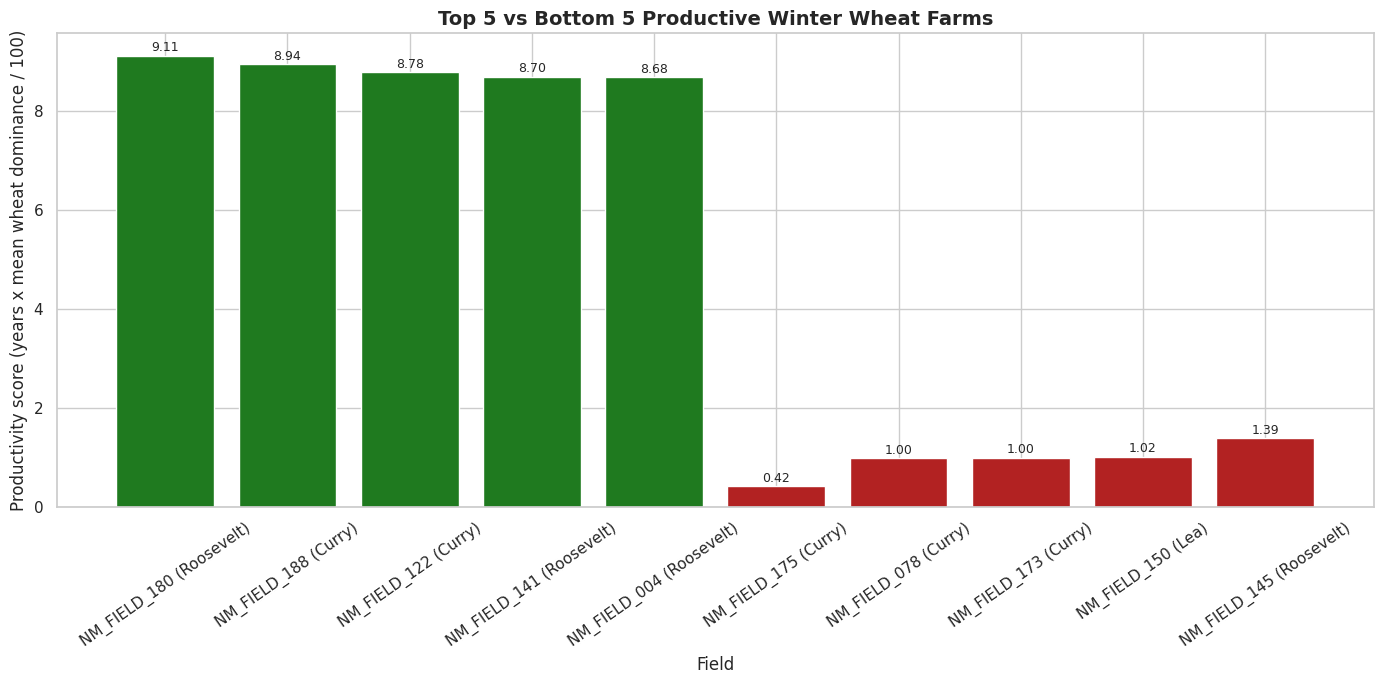

Saved: /workspaces/EVTLR-Project/output/dashboard_assets/wheat_productivity_top5_bottom5.png


In [8]:
plot_df = pd.concat([top5.assign(group="Top 5"), bottom5.assign(group="Bottom 5")], ignore_index=True)
plot_df["label"] = plot_df["field_id"] + " (" + plot_df["county"].fillna("Unknown") + ")"

fig, ax = plt.subplots(figsize=(14, 7))
colors = plot_df["group"].map({"Top 5": "#1f7a1f", "Bottom 5": "#b22222"})
ax.bar(plot_df["label"], plot_df["productivity_score"], color=colors)
ax.set_title("Top 5 vs Bottom 5 Productive Winter Wheat Farms", fontsize=14, fontweight="bold")
ax.set_ylabel("Productivity score (years x mean wheat dominance / 100)")
ax.set_xlabel("Field")
ax.tick_params(axis="x", rotation=35)
for i, value in enumerate(plot_df["productivity_score"]):
    ax.text(i, value + 0.03, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()

out_wheat = DASHBOARD_ASSETS_DIR / "wheat_productivity_top5_bottom5.png"
fig.savefig(out_wheat, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_wheat}")


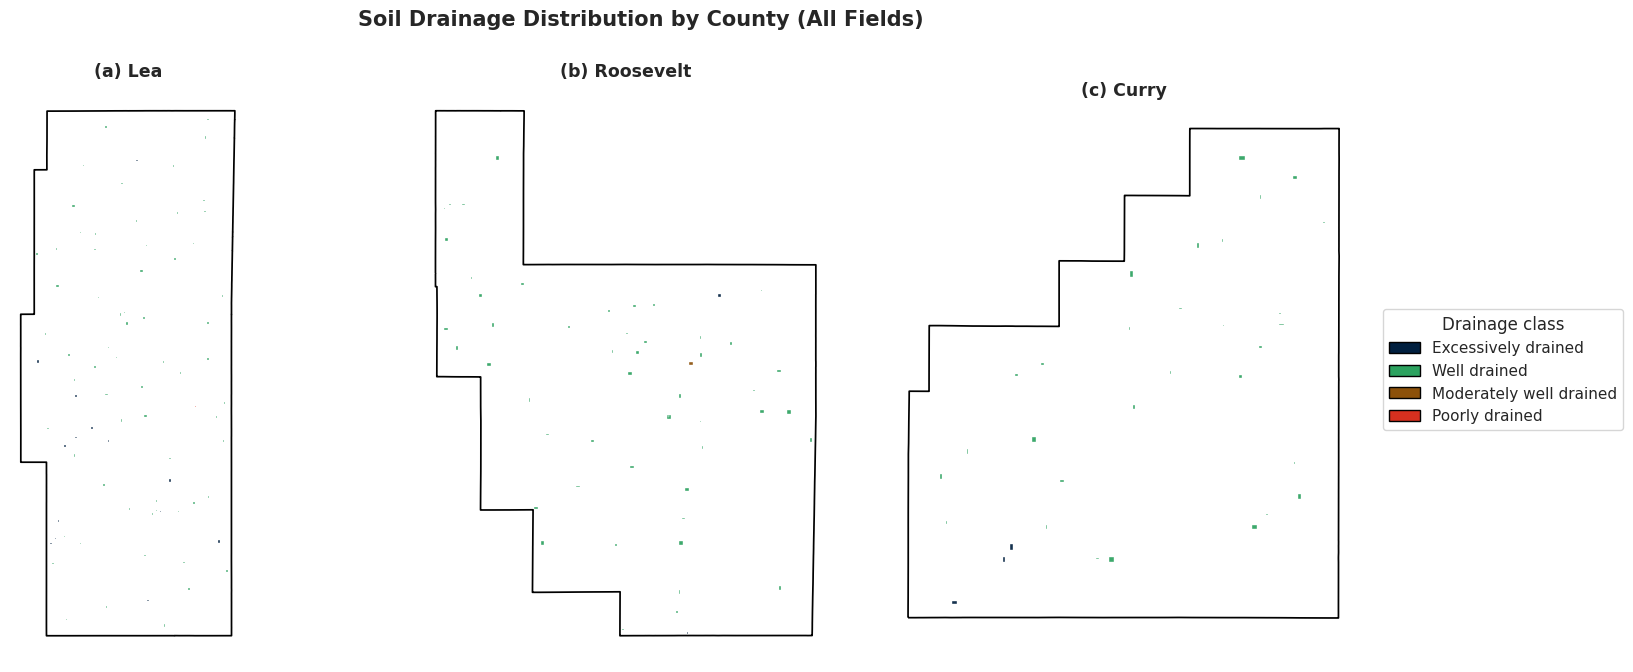

Saved: /workspaces/EVTLR-Project/output/dashboard_assets/soil_drainage_distribution_map.png


In [9]:
drainage_map = fields_gdf[["field_id", "county", "drainage", "geometry"]].copy()


def classify_drainage(value: str) -> str:
    text = str(value).lower()
    if "excessively" in text:
        return "Excessively drained"
    if "moderately" in text:
        return "Moderately well drained"
    if "poorly" in text:
        return "Poorly drained"
    if "well drained" in text:
        return "Well drained"
    return "Poorly drained"


drainage_map["drainage_class"] = drainage_map["drainage"].map(classify_drainage)

plot_fields = drainage_map.to_crs(epsg=3857)
plot_counties = counties_gdf.to_crs(epsg=3857)

class_order = [
    "Excessively drained",
    "Well drained",
    "Moderately well drained",
    "Poorly drained",
]

palette = {
    "Excessively drained": "#001f3f",  # navy blue
    "Well drained": "#2ca25f",  # green
    "Moderately well drained": "#8c510a",  # brown
    "Poorly drained": "#d7301f",  # red
}

county_order = ["Lea", "Roosevelt", "Curry"]
panel_labels = {"Lea": "(a)", "Roosevelt": "(b)", "Curry": "(c)"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7.5))

for ax, county in zip(axes, county_order):
    county_boundary = plot_counties[plot_counties["NAME"] == county]
    county_fields = plot_fields[plot_fields["county"] == county].copy()

    county_fields["drainage_class"] = pd.Categorical(
        county_fields["drainage_class"], categories=class_order, ordered=True
    )

    county_fields.plot(
        ax=ax,
        color=county_fields["drainage_class"].map(palette),
        edgecolor="white",
        linewidth=0.30,
        alpha=0.92,
    )
    county_boundary.boundary.plot(ax=ax, color="black", linewidth=1.25)

    ax.set_title(f"{panel_labels[county]} {county}", fontsize=12.5, fontweight="bold")
    ax.set_axis_off()

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=palette[label], edgecolor="black", label=label)
    for label in class_order
]

fig.suptitle(
    "Soil Drainage Distribution by County (All Fields)",
    fontsize=15,
    fontweight="bold",
)
fig.subplots_adjust(right=0.86, wspace=0.05)
fig.legend(
    handles=legend_handles,
    title="Drainage class",
    loc="center right",
    bbox_to_anchor=(0.995, 0.5),
    frameon=True,
)

out_drainage = DASHBOARD_ASSETS_DIR / "soil_drainage_distribution_map.png"
fig.savefig(out_drainage, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_drainage}")


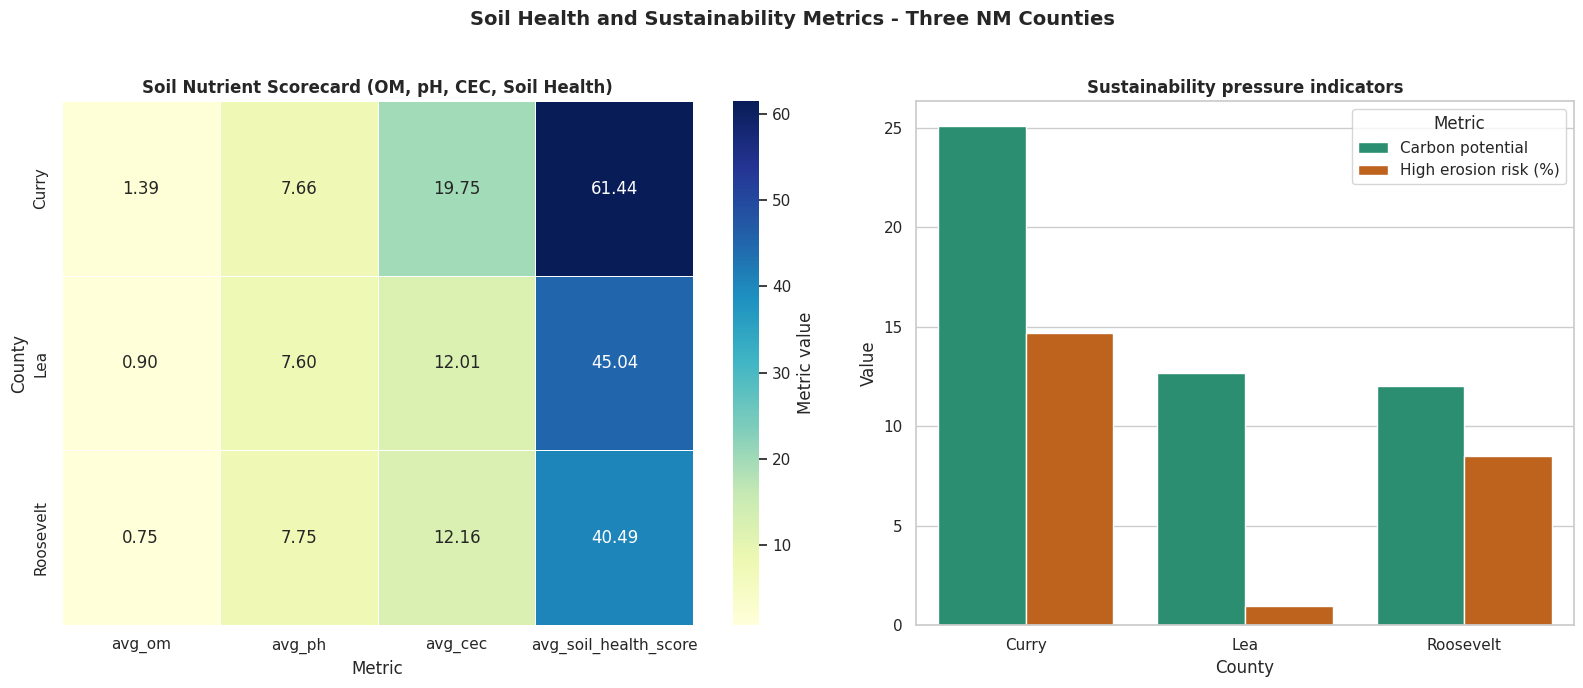

Saved: /workspaces/EVTLR-Project/output/dashboard_assets/soil_health_metrics.png


,county,avg_soil_health_score,avg_om,avg_ph,avg_cec,avg_carbon_potential,pct_high_erosion
0,Curry,61.438582,1.386525,7.660050,19.752701,25.073173,14.705882
1,Lea,45.040415,0.896994,7.601744,12.009057,12.655091,0.943396
2,Roosevelt,40.492186,0.747275,7.751813,12.155111,12.022609,8.474576


In [10]:
county_summary = field_metrics.groupby("county", as_index=False).agg(
    avg_soil_health_score=("soil_health_score", "mean"),
    avg_om=("om_weighted", "mean"),
    avg_ph=("ph_weighted", "mean"),
    avg_cec=("cec_weighted", "mean"),
    avg_carbon_potential=("carbon_storage_potential", "mean"),
    pct_high_erosion=("erosion_risk", lambda s: (s == "High").mean() * 100),
)

county_summary = county_summary.sort_values("avg_soil_health_score", ascending=False)

heatmap_df = county_summary.set_index("county")[["avg_om", "avg_ph", "avg_cec", "avg_soil_health_score"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.2, 1.0]})

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Metric value"},
    ax=axes[0],
)
axes[0].set_title("Soil Nutrient Scorecard (OM, pH, CEC, Soil Health)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("County")

bar_df = county_summary.melt(
    id_vars="county",
    value_vars=["avg_carbon_potential", "pct_high_erosion"],
    var_name="metric",
    value_name="value",
)
bar_df["metric"] = bar_df["metric"].map({
    "avg_carbon_potential": "Carbon potential",
    "pct_high_erosion": "High erosion risk (%)",
})

sns.barplot(data=bar_df, x="county", y="value", hue="metric", ax=axes[1], palette=["#1b9e77", "#d95f02"])
axes[1].set_title("Sustainability pressure indicators", fontsize=12, fontweight="bold")
axes[1].set_xlabel("County")
axes[1].set_ylabel("Value")
axes[1].legend(title="Metric")

fig.suptitle("Soil Health and Sustainability Metrics - Three NM Counties", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

out_scorecard = DASHBOARD_ASSETS_DIR / "soil_health_metrics.png"
fig.savefig(out_scorecard, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_scorecard}")

display(county_summary)


In [11]:
field_metrics_out = DATA_DIR / "assignment-02" / "soil_health_field_metrics_assignment_08.csv"
field_metrics.to_csv(field_metrics_out, index=False)
print(f"Saved field-level metrics: {field_metrics_out}")


Saved field-level metrics: /workspaces/EVTLR-Project/data/assignment-02/soil_health_field_metrics_assignment_08.csv
